# C02 · Premier League: team strengths, a title race and a fight with the bookmaker

| | |
|---|---|
| **Difficulty** | ★★★☆☆ |
| **Time** | 3-4 hours |
| **Data** | football-data.co.uk: every Premier League match of 2024/25 and 2025/26, with Bet365 odds |
| **Skills** | Poisson regression with crossed group effects · diagnosing non-identifiability · `pm.ZeroSumNormal` · hierarchical shrinkage · posterior predictive checks on quantities the model never saw · simulating a season from the posterior predictive · proper scoring rules against a market benchmark |

## The brief

You have joined the analytics desk of a sports media company. The editor wants two things:

1. **Team strength estimates** - attack and defence ratings with honest uncertainty, not a
   league table with extra steps.
2. **Probabilistic forecasts** - "Arsenal have an X% chance of the title, West Ham a Y%
   chance of going down" - that the desk can publish mid-season without embarrassing itself.

The head of the desk is a sceptic: *"Bookmakers do this for a living. Show me your numbers
next to theirs on matches your model has not seen, then we talk."*

You will build the model on the complete 2024/25 season, then deploy it on 2025/26 as it
stood on **13 February 2026** - 26 rounds played, 12 to go - and forecast the rest. We know
how the season ended, so we can mark your homework.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", home=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

from pymc_challenges import Hints, data

RANDOM_SEED = 2526
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C02")
h.tasks()

**C02 - Premier League: team strengths, a title race and a fight with the bookmaker**

- `task0` - Look at the data (2 hints, 2 check(s))
- `task1` - The textbook model and what is wrong with it (3 hints, 1 check(s))
- `task2` - An identified, hierarchical model (3 hints, 3 check(s))
- `task3` - Posterior predictive checks on results (3 hints, 1 check(s))
- `task4` - Forecast the run-in (3 hints, 3 check(s))
- `task5` - Scoring against the bookmaker (3 hints, 3 check(s))
- `task6` - Would you bet on it? (3 hints, 1 check(s))

## The data

One row per match. The columns you need: `HomeTeam`, `AwayTeam`, full-time home and away
goals `FTHG` and `FTAG`, the full-time result `FTR` (`H`, `D` or `A`), and Bet365's
pre-match decimal odds `B365H`, `B365D`, `B365A` (a winning 1-unit bet at odds 2.5 pays
back 2.5). There are many more columns (shots, cards, other bookmakers); ignore them or
use them in "Going further".

In [2]:
COLUMNS = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "B365H", "B365D", "B365A"]


def prepare(df):
    df = df[COLUMNS].copy()
    df["Date"] = pd.to_datetime(df.Date, dayfirst=True)
    return df.sort_values("Date", kind="stable").reset_index(drop=True)


data.describe("epl_2425")
epl25 = prepare(data.load("epl_2425"))
epl25.head()

epl_2425: All 380 match results with goals, shots and bookmaker odds.
  source: football-data.co.uk, English Premier League 2024/25.
  url:    https://www.football-data.co.uk/mmz4281/2425/E0.csv


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A
0,2024-08-16,Man United,Fulham,1,0,H,1.60,4.20,5.25
1,2024-08-17,Ipswich,Liverpool,0,2,A,8.50,5.50,1.33
2,2024-08-17,Arsenal,Wolves,2,0,H,1.18,7.50,13.00
3,2024-08-17,Everton,Brighton,0,3,A,2.63,3.30,2.63
4,2024-08-17,Newcastle,Southampton,1,0,H,1.36,5.25,8.00


A helper for the bookkeeping, so you can spend your time on the modelling. Ties on points
are broken by goal difference, then goals scored.

In [3]:
def league_table(df):
    """League table (points, goals for/against, goal difference) from a frame of matches."""
    home = pd.DataFrame({"team": df.HomeTeam, "gf": df.FTHG, "ga": df.FTAG})
    away = pd.DataFrame({"team": df.AwayTeam, "gf": df.FTAG, "ga": df.FTHG})
    long = pd.concat([home, away])
    long["played"] = 1
    long["pts"] = np.select([long.gf > long.ga, long.gf == long.ga], [3, 1], 0)
    table = long.groupby("team")[["played", "pts", "gf", "ga"]].sum()
    table["gd"] = table.gf - table.ga
    table = table.sort_values(["pts", "gd", "gf"], ascending=False)
    table.insert(0, "pos", range(1, len(table) + 1))
    return table


league_table(epl25)

,pos,played,pts,gf,ga,gd
team,,,,,,
Liverpool,1,38,84,86,41,45
Arsenal,2,38,74,69,34,35
Man City,3,38,71,72,44,28
Chelsea,4,38,69,64,43,21
Newcastle,5,38,66,68,47,21
Aston Villa,6,38,66,58,51,7
Nott'm Forest,7,38,65,58,46,12
Brighton,8,38,61,66,59,7
Bournemouth,9,38,56,58,46,12


## Task 0 · Look at the data

Use the 2024/25 season.

**Deliver**
1. How large is home advantage - in goals and in results?
2. Are goals plausibly Poisson? Compare the observed distribution of home goals and of
   away goals with a Poisson of the same mean, and compare means with variances.
3. One sentence: is a Poisson likelihood a defensible starting point?

goals per match   home 1.513 (variance 1.633)   away 1.421 (variance 1.416)
results: {'H': 0.408, 'A': 0.347, 'D': 0.245}
correlation between home and away goals: -0.142


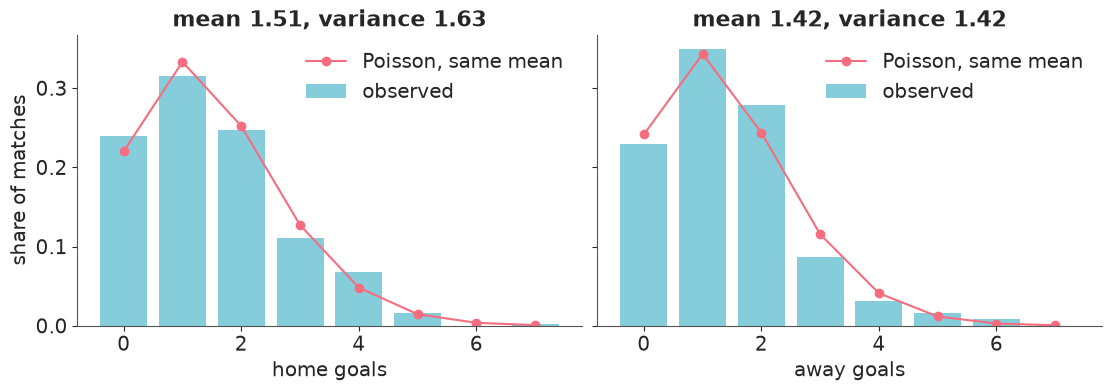

In [4]:
print("goals per match   home %.3f (variance %.3f)   away %.3f (variance %.3f)"
      % (epl25.FTHG.mean(), epl25.FTHG.var(), epl25.FTAG.mean(), epl25.FTAG.var()))
print("results:", epl25.FTR.value_counts(normalize=True).round(3).to_dict())
print("correlation between home and away goals: %.3f" % np.corrcoef(epl25.FTHG, epl25.FTAG)[0, 1])

goals = np.arange(0, 8)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, col, label in zip(axes, ["FTHG", "FTAG"], ["home goals", "away goals"]):
    observed = epl25[col].value_counts(normalize=True).reindex(goals, fill_value=0)
    ax.bar(goals, observed, alpha=0.6, label="observed")
    ax.plot(goals, stats.poisson.pmf(goals, epl25[col].mean()), "o-", color="C1", label="Poisson, same mean")
    ax.set(xlabel=label, title=f"mean {epl25[col].mean():.2f}, variance {epl25[col].var():.2f}")
    ax.legend()
axes[0].set(ylabel="share of matches");

In [5]:
assert h.check("task0", home_goals_mean=epl25.FTHG.mean(), away_goals_mean=epl25.FTAG.mean())

- PASS `home_goals_mean` = 1.513 is consistent with the reference solution.
- PASS `away_goals_mean` = 1.421 is consistent with the reference solution.

Home teams scored 1.51 goals per match against 1.42 for away teams, and won 41% of
matches against 35% - a real but, in this particular season, modest home advantage.

The marginal goal distributions sit close to a Poisson with the same mean, and variances
are close to the means (1.63 vs 1.51 at home, almost identical away). Note that this is the
*marginal* distribution over all fixtures: a mixture of Poissons with different rates
(Liverpool at home to Southampton, and the reverse) must be somewhat overdispersed, so a
variance slightly above the mean is what a Poisson model with team effects predicts. The
same goes for the negative correlation between home and away goals (-0.14): strong teams
score a lot *and* concede little, so it need not mean that goals within a match depend on
each other. Poisson is a defensible starting point; we will check it properly in Task 3.

## Task 1 · The textbook model

The classic model for football scores gives every team an **attack** and a **defence**
rating. For a match between home team $h$ and away team $a$:

$$
\begin{aligned}
\text{home goals} &\sim \text{Poisson}(\lambda_h), & \log \lambda_h &= \mu + \eta + \text{att}_h - \text{def}_a \\
\text{away goals} &\sim \text{Poisson}(\lambda_a), & \log \lambda_a &= \mu + \text{att}_a - \text{def}_h
\end{aligned}
$$

with $\mu$ an intercept and $\eta$ the home advantage. A colleague suggests
"uninformative priors, let the data speak": independent `Normal(0, 3)` on $\mu$, on $\eta$
and on every $\text{att}$ and $\text{def}$.

**Deliver**
1. Fit exactly this model to 2024/25 with default sampler settings, using `coords`/`dims`
   for teams.
2. Read the diagnostics. Something is wrong. **Explain what, in terms of the model** - not
   in terms of the sampler - and produce one plot or table that demonstrates your explanation.
3. Which quantities does this posterior pin down well in spite of the problem, and which
   not at all? Give one example of each, with numbers.

### Solution

In [6]:
def team_codes(names, teams):
    return pd.Categorical(names, categories=teams).codes


teams25 = np.sort(epl25.HomeTeam.unique())
home25, away25 = team_codes(epl25.HomeTeam, teams25), team_codes(epl25.AwayTeam, teams25)

with pm.Model(coords={"team": teams25}) as naive_model:
    intercept = pm.Normal("intercept", 0, 3)
    home = pm.Normal("home", 0, 3)
    attack = pm.Normal("attack", 0, 3, dims="team")
    defence = pm.Normal("defence", 0, 3, dims="team")
    pm.Poisson("home_goals", pm.math.exp(intercept + home + attack[home25] - defence[away25]), observed=epl25.FTHG.values)
    pm.Poisson("away_goals", pm.math.exp(intercept + attack[away25] - defence[home25]), observed=epl25.FTAG.values)
    naive_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(naive_idata.sample_stats["diverging"].sum()))
az.summary(naive_idata, var_names=["intercept", "home", "attack"], coords={"team": ["Liverpool", "Southampton"]}, round_to=2)

NUTS[nutpie]: [intercept, home, attack, defence]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.24,0.85,-1.29,1.53,59.56,52.48,1.05,0.11,0.07
home,0.06,0.06,-0.03,0.16,1992.18,2384.58,1.00,0.00,0.00
attack[Liverpool],0.50,0.58,-0.56,1.36,58.10,58.88,1.08,0.08,0.07
attack[Southampton],-0.66,0.60,-1.74,0.22,61.28,69.93,1.08,0.08,0.07


No divergences - but `r_hat` of 1.05-1.08 and a bulk ESS of about 60 for the intercept and
the team effects: four chains, 4000 draws, and the information of sixty. Yet `home`, in the
same model, has an ESS of 2000 and `r_hat` of 1.00. That contrast is the clue.

Look at the posterior sd of the attack ratings: about 0.6 on the log scale, i.e. we
supposedly cannot tell whether Liverpool score 0.5x or 2x what an average team does,
after 38 matches. Now look at a *difference* between two teams:

sd of attack[Liverpool]                       : 0.58
sd of attack[Southampton]                     : 0.60
sd of attack[Liverpool] - attack[Southampton] : 0.22
sd of intercept                               : 0.85
sd of intercept + mean(attack) - mean(defence): 0.04


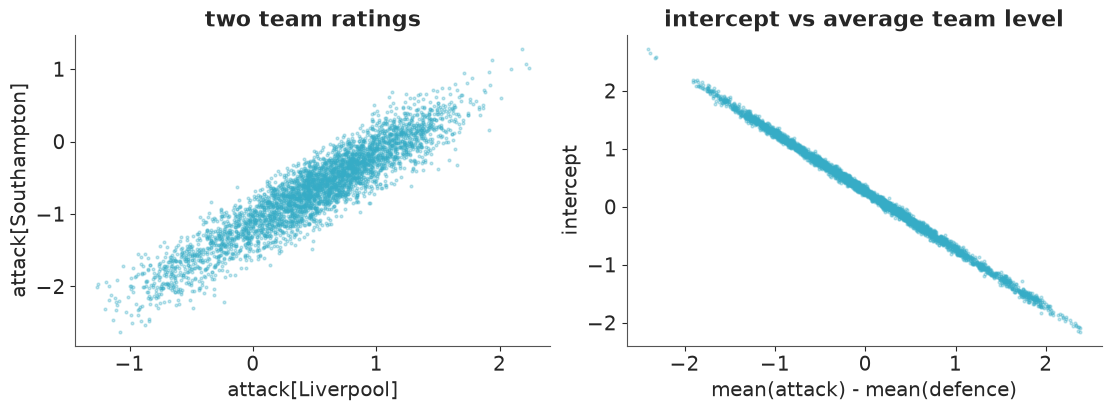

In [7]:
post = naive_idata.posterior
difference = post["attack"].sel(team="Liverpool") - post["attack"].sel(team="Southampton")
level = post["attack"].mean("team") - post["defence"].mean("team")

print("sd of attack[Liverpool]                       : %.2f" % post["attack"].sel(team="Liverpool").std())
print("sd of attack[Southampton]                     : %.2f" % post["attack"].sel(team="Southampton").std())
print("sd of attack[Liverpool] - attack[Southampton] : %.2f" % difference.std())
print("sd of intercept                               : %.2f" % post["intercept"].std())
print("sd of intercept + mean(attack) - mean(defence): %.2f" % (post["intercept"] + level).std())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(post["attack"].sel(team="Liverpool"), post["attack"].sel(team="Southampton"), s=4, alpha=0.3)
axes[0].set(xlabel="attack[Liverpool]", ylabel="attack[Southampton]", title="two team ratings")
axes[1].scatter(level, post["intercept"], s=4, alpha=0.3)
axes[1].set(xlabel="mean(attack) - mean(defence)", ylabel="intercept", title="intercept vs average team level");

In [8]:
assert h.check("task1", sd_attack_difference=difference.std())

- PASS `sd_attack_difference` = 0.2232 is consistent with the reference solution.

The model is **not identifiable**. The likelihood only ever sees the sums
$\mu + \text{att}_i - \text{def}_j$, and those are unchanged if you

- add a constant to every attack rating and subtract it from $\mu$, or
- add the same constant to every attack *and* every defence rating.

So there are two directions in parameter space along which the data say nothing at all.
The posterior is a long, thin ridge (both panels): its *length* is set purely by the prior
- make the prior wider and the ridge gets longer - while its *width* is what the data
determined. NUTS has to crawl along it, hence the dismal ESS. It would be a mistake to "fix"
this with more draws or a higher `target_accept`: the sampler is reporting a real property
of the model.

What *is* pinned down: differences between teams (sd about 0.22 instead of 0.6), the home
advantage, and the overall scoring level $\mu + \overline{\text{att}} - \overline{\text{def}}$
(sd 0.04, against 0.85 for $\mu$ on its own). Those are the identified quantities, and the
fix is to parameterise the model so that only they are free.

## Task 2 · An identified, hierarchical model

**Deliver**
1. A reformulated model in which every parameter is identified **by construction** (not by
   luck of the prior), and in which the *spread* of attacking and of defensive ability
   across the league is learned from the data rather than fixed by you.
2. Priors you can defend, backed by a prior predictive check on a scale a football fan
   would recognise.
3. Clean diagnostics, and a comparison with Task 1: what happened to the effective sample size?
4. A plot of attack and defence ratings with uncertainty. Then compare your attack ratings
   with the naive estimate "log of goals scored relative to the league average". Which way
   does the model move teams, and why?

### Solution

`pm.ZeroSumNormal` constrains the ratings to sum to zero across teams, which removes both
flat directions at once: attack ratings are now "relative to the average team", and the
intercept is unambiguously the log scoring rate of an average away team against an average
defence. Giving the ratings a learned scale `sigma_att`, `sigma_def` makes the model
hierarchical: teams are shrunk towards the league average by an amount the data choose.

Priors, on the log scale: teams score around 1-2 goals a match, so `intercept ~ Normal(0, 0.5)`
covers rates from about 0.4 to 2.7. Home advantage multiplies scoring by maybe 1.1-1.4;
`Normal(0, 0.25)`. A rating sd of 0.5 would already mean the best attacks score
$e^{1} \approx 2.7$ times the average, so `HalfNormal(0.5)` is generous.

The model is wrapped in a function with `pm.Data` inputs because we will fit it again to
another season and predict fixtures it has not seen. (The `noncentred` switch is for Task 4.)

In [9]:
def build_model(df, teams, noncentred=False):
    coords = {"team": teams, "match": df.index.values}
    with pm.Model(coords=coords) as model:
        home_idx = pm.Data("home_idx", team_codes(df.HomeTeam, teams), dims="match")
        away_idx = pm.Data("away_idx", team_codes(df.AwayTeam, teams), dims="match")

        intercept = pm.Normal("intercept", 0, 0.5)
        home = pm.Normal("home", 0, 0.25)
        sigma_att = pm.HalfNormal("sigma_att", 0.5)
        sigma_def = pm.HalfNormal("sigma_def", 0.5)
        if noncentred:  # same model, different geometry for the sampler - see E02
            attack = pm.Deterministic("attack", sigma_att * pm.ZeroSumNormal("attack_z", sigma=1, dims="team"), dims="team")
            defence = pm.Deterministic("defence", sigma_def * pm.ZeroSumNormal("defence_z", sigma=1, dims="team"), dims="team")
        else:
            attack = pm.ZeroSumNormal("attack", sigma=sigma_att, dims="team")
            defence = pm.ZeroSumNormal("defence", sigma=sigma_def, dims="team")

        mu_home = pm.Deterministic("mu_home", pm.math.exp(intercept + home + attack[home_idx] - defence[away_idx]), dims="match")
        mu_away = pm.Deterministic("mu_away", pm.math.exp(intercept + attack[away_idx] - defence[home_idx]), dims="match")
        pm.Poisson("home_goals", mu_home, observed=df.FTHG.values, dims="match", shape=mu_home.shape)
        pm.Poisson("away_goals", mu_away, observed=df.FTAG.values, dims="match", shape=mu_away.shape)
    return model


PARAMS = ["intercept", "home", "sigma_att", "sigma_def"]
model25 = build_model(epl25, teams25)

with model25:
    idata25 = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)

prior_goals = idata25.prior_predictive["home_goals"].values.ravel()
print("prior predictive home goals - quantiles 50% / 90% / 99%:", np.quantile(prior_goals, [0.5, 0.9, 0.99]))
print("share of simulated teams scoring more than 7 in a match: %.3f" % (prior_goals > 7).mean())

Sampling: [attack, away_goals, defence, home, home_goals, intercept, sigma_att, sigma_def]


prior predictive home goals - quantiles 50% / 90% / 99%: [1. 3. 9.]
share of simulated teams scoring more than 7 in a match: 0.017


A median of one goal, nine in ten simulated performances at three goals or fewer, and
just under 2% at more than seven. No side scored more than seven in either season of our
data, so the prior is generous in the tail - which is what weakly informative means - but
nothing absurd dominates. Fit:

In [10]:
with model25:
    idata25.update(pm.sample(random_seed=RANDOM_SEED))

print("divergences:", int(idata25.sample_stats["diverging"].sum()))
az.summary(idata25, var_names=PARAMS, ci_kind="hdi", ci_prob=0.94, round_to=3)

NUTS[nutpie]: [intercept, home, sigma_att, sigma_def, attack, defence]


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.304,0.044,0.223,0.386,3254.403,3217.859,1.003,0.001,0.001
home,0.061,0.059,-0.060,0.162,3417.038,3209.177,1.001,0.001,0.001
sigma_att,0.248,0.060,0.141,0.357,2379.264,2629.246,1.003,0.001,0.001
sigma_def,0.219,0.052,0.129,0.315,2575.697,2571.945,1.001,0.001,0.001


In [11]:
def min_ess(idata):
    """Smallest bulk ESS within each (group of) parameter(s)."""
    s = az.summary(idata, var_names=["intercept", "home", "attack", "defence"])
    return s.ess_bulk.groupby(s.index.str.split("[").str[0]).min()


ess = pd.DataFrame({"naive": min_ess(naive_idata), "zero-sum hierarchical": min_ess(idata25)}).round(0)
ess.index.name = "minimum bulk ESS"
ess

,naive,zero-sum hierarchical
minimum bulk ESS,,
attack,58.0,4222.0
defence,30.0,4557.0
home,1992.0,3417.0
intercept,60.0,3254.0


In [12]:
assert h.check(
    "task2",
    home=idata25.posterior["home"].mean(),
    sigma_att=idata25.posterior["sigma_att"].mean(),
    sigma_def=idata25.posterior["sigma_def"].mean(),
)

- PASS `home` = 0.06145 is consistent with the reference solution.
- PASS `sigma_att` = 0.2482 is consistent with the reference solution.
- PASS `sigma_def` = 0.2192 is consistent with the reference solution.

Same likelihood, same data; ESS is 50 to 150 times higher for the intercept and the
ratings, because the ridge is gone. (`home` was identified all along and barely changes.)

The home advantage in 2024/25 is small: about +6% goals, with an interval that includes
zero. Team abilities have an sd of roughly 0.25 (attack) and 0.22 (defence) on the log
scale.

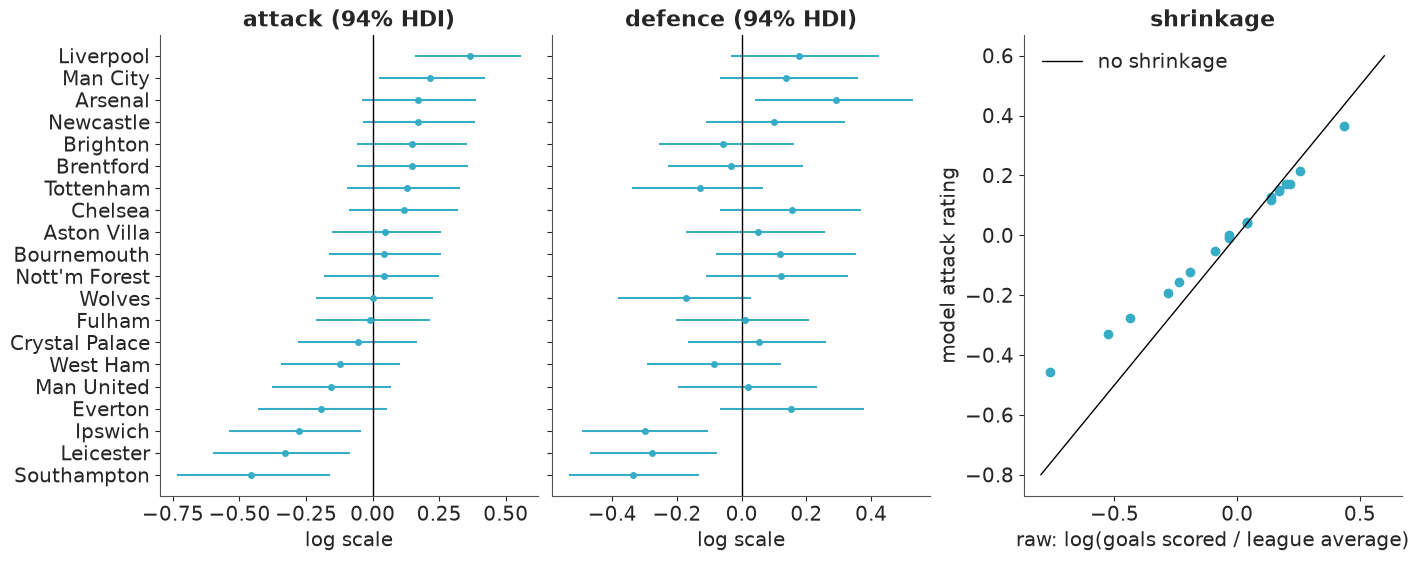

In [13]:
def rating_table(idata, teams):
    post = idata.posterior
    out = pd.DataFrame(index=teams)
    for var in ["attack", "defence"]:
        hdi = az.hdi(post[var], prob=0.94)
        out[var] = post[var].mean(("chain", "draw")).values
        out[f"{var}_lo"], out[f"{var}_hi"] = hdi.sel(ci_bound="lower").values, hdi.sel(ci_bound="upper").values
    return out


ratings25 = rating_table(idata25, teams25).sort_values("attack")
goals_for = league_table(epl25).gf.loc[ratings25.index]
ratings25["raw_attack"] = np.log(goals_for / goals_for.mean())

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
ypos = np.arange(len(ratings25))
for ax, var in zip(axes, ["attack", "defence"]):
    r = ratings25
    ax.errorbar(r[var], ypos, xerr=[r[var] - r[f"{var}_lo"], r[f"{var}_hi"] - r[var]], fmt="o", ms=4)
    ax.axvline(0, color="k", lw=1)
    ax.set(yticks=ypos, yticklabels=r.index if var == "attack" else [], title=f"{var} (94% HDI)", xlabel="log scale")
axes[2].scatter(ratings25.raw_attack, ratings25.attack)
lim = [-0.8, 0.6]
axes[2].plot(lim, lim, color="k", lw=1, label="no shrinkage")
axes[2].set(xlabel="raw: log(goals scored / league average)", ylabel="model attack rating", title="shrinkage")
axes[2].legend();

In [14]:
slope = np.polyfit(ratings25.raw_attack, ratings25.attack, 1)[0]
print(f"slope of model rating on raw rating: {slope:.2f}")

slope of model rating on raw rating: 0.69


Liverpool's attack and Arsenal's defence stand out at the top; the three relegated sides
(Southampton, Ipswich, Leicester) are clearly the worst at both ends. But intervals are
wide: after a full season, most mid-table teams cannot be separated.

The model's ratings are a compressed version of the raw ones, by about 30% (slope 0.69):
extreme scoring records are partly luck, and the hierarchical prior says so. Southampton's
26 goals in 38 matches were bad, but the model's best guess is that their attack was not
quite *that* bad. Nobody chose the 30%: it follows from `sigma_att` and from how much a
season of goals can tell you about one team.

## Task 3 · Check the model against things it was not fitted to

The model was fitted to home goals and away goals, separately. Football is about
**results**. A model can match both goal distributions and still get the things people
care about wrong.

**Deliver** posterior predictive checks, each with a verdict, for
1. the **share of draws** in a season,
2. the frequency of the most common **scorelines** (0-0, 1-1, 1-0, ...),
3. one further statistic of your choice that the likelihood does not target directly.

Does anything fail badly enough to matter for forecasting results?

Sampling: [away_goals, home_goals]


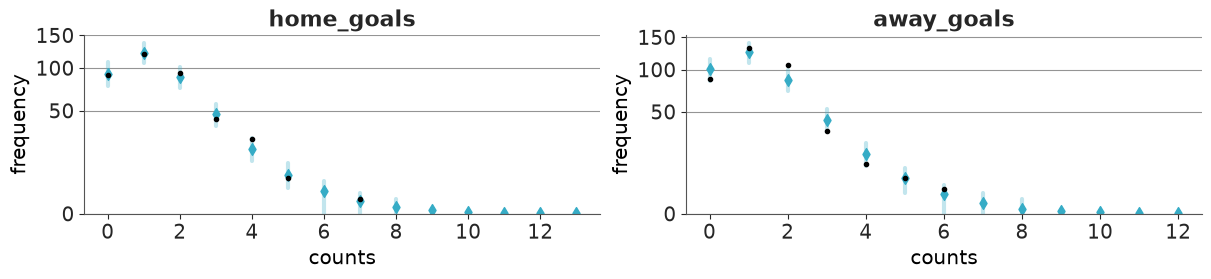

In [15]:
with model25:
    pm.sample_posterior_predictive(idata25, extend_inferencedata=True, random_seed=RANDOM_SEED)

az.plot_ppc_rootogram(idata25, var_names=["home_goals", "away_goals"]);

The rootograms cover what the model *was* fitted to: observed counts (black) sit inside or
at the edge of the predictive intervals. Now for what it was not. Each posterior predictive
draw is one replicated season of 380 matches:

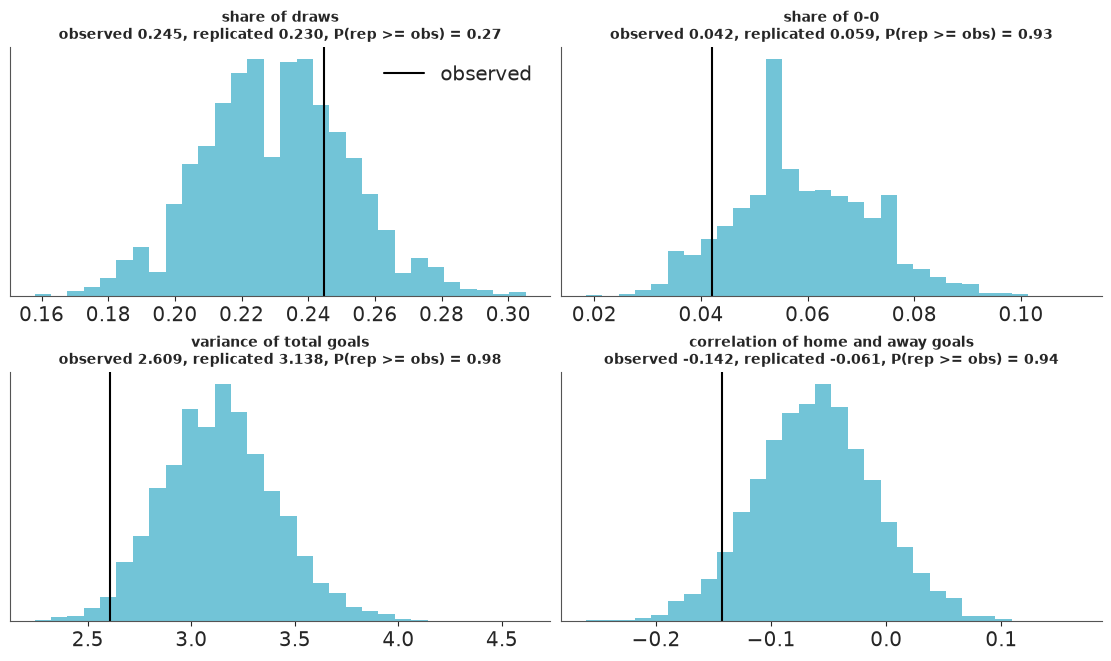

In [16]:
pp = az.extract(idata25, group="posterior_predictive", var_names=["home_goals", "away_goals"])
hg_rep, ag_rep = pp["home_goals"].values, pp["away_goals"].values  # (match, sample)
hg_obs, ag_obs = epl25.FTHG.values[:, None], epl25.FTAG.values[:, None]

def correlation(hg, ag):
    hg, ag = hg - hg.mean(axis=0), ag - ag.mean(axis=0)
    return (hg * ag).mean(axis=0) / (hg.std(axis=0) * ag.std(axis=0))


statistics = {
    "share of draws": lambda hg, ag: (hg == ag).mean(axis=0),
    "share of 0-0": lambda hg, ag: ((hg == 0) & (ag == 0)).mean(axis=0),
    "variance of total goals": lambda hg, ag: (hg + ag).var(axis=0),
    "correlation of home and away goals": correlation,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, (name, fn) in zip(axes.ravel(), statistics.items()):
    rep, obs = fn(hg_rep, ag_rep), fn(hg_obs, ag_obs)[0]
    ax.hist(rep, bins=30, alpha=0.7)
    ax.axvline(obs, color="k", label="observed")
    ax.set(title=f"{name}\nobserved {obs:.3f}, replicated {rep.mean():.3f}, P(rep >= obs) = {(rep >= obs).mean():.2f}", yticks=[])
    ax.title.set_fontsize(10)
axes[0, 0].legend();

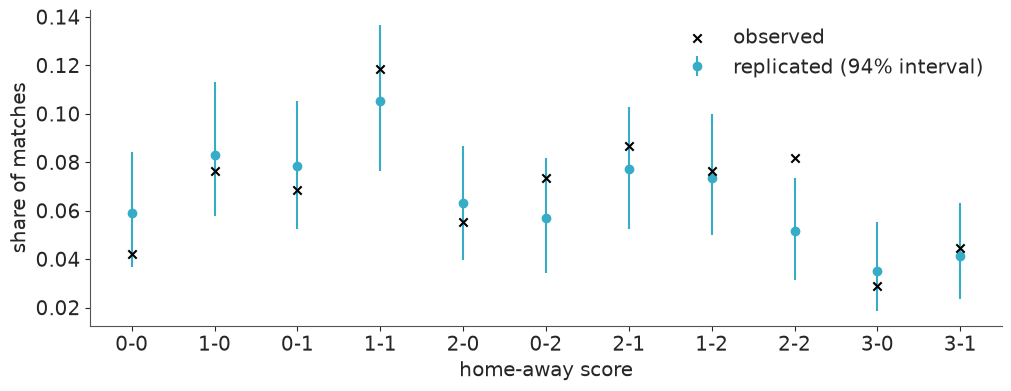

In [17]:
scorelines = [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (2, 1), (1, 2), (2, 2), (3, 0), (3, 1)]
rows = []
for i, j in scorelines:
    rep = ((hg_rep == i) & (ag_rep == j)).mean(axis=0)
    rows.append({"score": f"{i}-{j}", "observed": ((hg_obs == i) & (ag_obs == j)).mean(),
                 "replicated": rep.mean(), "lo": np.quantile(rep, 0.03), "hi": np.quantile(rep, 0.97)})
score_table = pd.DataFrame(rows).set_index("score")

fig, ax = plt.subplots(figsize=(10, 3.8))
xs = np.arange(len(score_table))
ax.errorbar(xs, score_table.replicated, yerr=[score_table.replicated - score_table.lo, score_table.hi - score_table.replicated],
            fmt="o", color="C0", label="replicated (94% interval)")
ax.scatter(xs, score_table.observed, color="k", marker="x", zorder=3, label="observed")
ax.set(xticks=xs, xticklabels=score_table.index, xlabel="home-away score", ylabel="share of matches")
ax.legend();

In [18]:
assert h.check("task3", draw_share_replicated=statistics["share of draws"](hg_rep, ag_rep).mean())

- PASS `draw_share_replicated` = 0.2301 is consistent with the reference solution.

**Verdict.** The share of draws - the quantity most likely to embarrass a model built from
two independent Poissons - is reproduced: the model expects about 23%, the season had
24.5%, well inside the replicated range. Of the eleven most common scorelines, ten fall
inside their 94% intervals; only 2-2 was clearly more frequent than the model expects, and
0-0 was *rarer* than expected, though not alarmingly so.

The one check that comes close to failing is the third: the variance of total goals per
match was 2.6, and only about 2% of replicated seasons are that tame. The fourth panel
says where it comes from. Team effects alone do make home and away goals negatively
correlated in the replications (about -0.06), as we argued in Task 0, but the real season
had -0.14, further out than roughly 94% of replications. When one side scored more, the
other scored a little less than independence allows. Goals within a match are **mildly
dependent** - the finding that made Dixon & Coles (1997) famous, although their version
(too many 0-0 and 1-1) is not quite what this season shows.

Does it matter for forecasting results? The draw share and the scorelines say: not much.
Two tail probabilities of 0.02 and 0.06 among several checks on one season are a lead, not
a verdict. We proceed, and keep the dependence between the two scores in mind as the place
to look if the forecasts disappoint.

## Task 4 · Forecast the run-in

Now the live season. It is 13 February 2026: every team has played 26 of 38 matches.
`played` is what you may fit to; `remaining` holds the 120 fixtures still to come. (It
also holds their results and odds. Those are for marking - do not let the model see them.)

In [19]:
data.describe("epl_2526")
epl26 = prepare(data.load("epl_2526"))

CUTOFF = pd.Timestamp("2026-02-13")
played = epl26[epl26.Date < CUTOFF].reset_index(drop=True)
remaining = epl26[epl26.Date >= CUTOFF].reset_index(drop=True)

print(f"{len(played)} matches played, {len(remaining)} remaining")
league_table(played)

epl_2526: All 380 match results with goals, shots and bookmaker odds.
  source: football-data.co.uk, English Premier League 2025/26.
  url:    https://www.football-data.co.uk/mmz4281/2526/E0.csv
260 matches played, 120 remaining


,pos,played,pts,gf,ga,gd
team,,,,,,
Arsenal,1,26,57,50,18,32
Man City,2,26,53,54,24,30
Aston Villa,3,26,50,37,27,10
Man United,4,26,45,47,37,10
Chelsea,5,26,44,47,30,17
Liverpool,6,26,42,41,35,6
Brentford,7,26,40,40,35,5
Everton,8,26,37,29,30,-1
Bournemouth,9,26,37,43,45,-2


**Deliver**
1. Your Task 2 model fitted to `played`, with clean diagnostics.
2. Simulations of the 120 remaining fixtures from the **posterior predictive** (parameter
   uncertainty *and* match-day randomness), turned into complete final league tables -
   one table per posterior draw, with the usual tie-breakers.
3. For every team: expected final points with a 94% interval, **P(title)**, **P(top 4)**,
   **P(relegation)** (bottom three).
4. The reckoning: compare with `league_table(epl26)`. Were the favourites right? How many
   of the 20 final points totals fall inside your 94% intervals, and how many should?

### Solution

"Your Task 2 model, with clean diagnostics" hides a small trap. With 26 matches per team
instead of 38, `sigma_att` and `sigma_def` are less well determined and values near zero
become plausible - the funnel geometry of E02. Fit the model both ways and compare:

In [20]:
teams26 = np.sort(epl26.HomeTeam.unique())
fits26 = {}
for label, noncentred in [("centred", False), ("non-centred", True)]:
    with build_model(played, teams26, noncentred=noncentred) as model26:
        fits26[label] = pm.sample(random_seed=RANDOM_SEED)

rows = {}
for label, idata in fits26.items():
    summary = az.summary(idata, var_names=["sigma_att", "sigma_def"])
    rows[label] = {"divergences": int(idata.sample_stats["diverging"].sum()), "min ess_bulk": summary.ess_bulk.min(),
                   "min ess_tail": summary.ess_tail.min(), "max r_hat": summary.r_hat.max()}
pd.DataFrame(rows).T

NUTS[nutpie]: [intercept, home, sigma_att, sigma_def, attack, defence]


NUTS[nutpie]: [intercept, home, sigma_att, sigma_def, attack_z, defence_z]


,divergences,min ess_bulk,min ess_tail,max r_hat
centred,0.0,448.379024,316.528415,1.008097
non-centred,0.0,811.371386,607.096361,1.003756


Neither fit diverges, but the centred one is visibly less comfortable: for the two sigmas a
minimum bulk ESS of about 450 (tail: 320) and an `r_hat` of 1.008, against about 810 (610)
and 1.004 for the non-centred version. With the full season of Task 2 it is the other way
round (try it): the more the data say about every team, the better the centred form does.
The centred fit would pass, but title and relegation probabilities lean on the tails of the
posterior, so we take the better one.

In [21]:
idata26 = fits26["non-centred"]  # model26 is the non-centred model, the last one built in the loop
az.summary(idata26, var_names=PARAMS, ci_kind="hdi", ci_prob=0.94, round_to=3)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.183,0.056,0.078,0.286,2257.498,2399.078,1.003,0.001,0.001
home,0.209,0.074,0.068,0.341,2364.512,2363.149,1.003,0.002,0.001
sigma_att,0.210,0.062,0.104,0.338,1295.662,1511.186,1.004,0.002,0.001
sigma_def,0.172,0.066,0.039,0.302,811.371,607.096,1.003,0.002,0.002


One number stands out: `home` is 0.21, i.e. home sides score about 23% more - more than
three times last season's estimate, with an interval that excludes zero. Whether home
advantage really moves that much from one year to the next, or whether one of the two
seasons is a fluke, is something a single-season model cannot know. We will see in Task 6
what the bookmaker thinks.

Now swap the fixtures in with `pm.set_data` and sample the posterior predictive for the
unseen matches. We also keep the match rates `mu_home`, `mu_away` for Task 5.

In [22]:
with model26:
    pm.set_data(
        {"home_idx": team_codes(remaining.HomeTeam, teams26), "away_idx": team_codes(remaining.AwayTeam, teams26)},
        coords={"match": remaining.index.values},
    )
    forecast = pm.sample_posterior_predictive(
        idata26, var_names=["mu_home", "mu_away", "home_goals", "away_goals"], predictions=True, random_seed=RANDOM_SEED
    )

sims = az.extract(forecast, group="predictions")
hg_sim, ag_sim = sims["home_goals"].values, sims["away_goals"].values  # (match, sample)
hg_sim.shape

Sampling: [away_goals, home_goals]


(120, 4000)

Bookkeeping, vectorised over draws: start every simulated season from the real table on
13 February, add the simulated results, and rank with points, then goal difference, then
goals scored (scaled so that one number sorts all three; a tiny random term breaks exact ties).

In [23]:
def simulate_tables(current, fixtures, hg, ag, teams, rng):
    """Final points, goal difference and rank per team and draw, arrays of shape (team, sample)."""
    n_draws = hg.shape[1]
    start = current.loc[teams]
    pts = np.repeat(start.pts.values[:, None], n_draws, axis=1).astype(float)
    gd = np.repeat(start.gd.values[:, None], n_draws, axis=1).astype(float)
    gf = np.repeat(start.gf.values[:, None], n_draws, axis=1).astype(float)
    h_idx, a_idx = team_codes(fixtures.HomeTeam, teams), team_codes(fixtures.AwayTeam, teams)
    for k in range(len(fixtures)):
        pts[h_idx[k]] += np.select([hg[k] > ag[k], hg[k] == ag[k]], [3, 1], 0)
        pts[a_idx[k]] += np.select([ag[k] > hg[k], hg[k] == ag[k]], [3, 1], 0)
        gd[h_idx[k]] += hg[k] - ag[k]
        gd[a_idx[k]] += ag[k] - hg[k]
        gf[h_idx[k]] += hg[k]
        gf[a_idx[k]] += ag[k]
    order_key = pts * 1e6 + (gd + 500) * 1e3 + gf + rng.uniform(0, 0.5, size=pts.shape)
    rank = (-order_key).argsort(axis=0).argsort(axis=0) + 1
    return pts, gd, rank


pts_sim, gd_sim, rank_sim = simulate_tables(league_table(played), remaining, hg_sim, ag_sim, teams26, rng)
final = league_table(epl26)

outlook = pd.DataFrame({
    "pts_13_feb": league_table(played).pts.loc[teams26].values,
    "exp_pts": pts_sim.mean(axis=1),
    "lo": np.quantile(pts_sim, 0.03, axis=1),
    "hi": np.quantile(pts_sim, 0.97, axis=1),
    "P_title": (rank_sim == 1).mean(axis=1),
    "P_top4": (rank_sim <= 4).mean(axis=1),
    "P_relegation": (rank_sim >= 18).mean(axis=1),
}, index=teams26)
outlook["actual_pts"] = final.pts.loc[teams26]
outlook["actual_pos"] = final.pos.loc[teams26]
outlook = outlook.sort_values("actual_pos")
outlook.round(2)

,pts_13_feb,exp_pts,lo,hi,P_title,P_top4,P_relegation,actual_pts,actual_pos
Arsenal,57,79.15,70.00,88.00,0.72,1.00,0.00,85,1
Man City,53,74.19,65.00,83.00,0.24,0.98,0.00,78,2
Man United,45,63.27,54.00,73.00,0.00,0.44,0.00,71,3
Aston Villa,50,68.63,60.00,78.00,0.03,0.82,0.00,65,4
Liverpool,42,60.09,51.00,69.00,0.00,0.20,0.00,60,5
Bournemouth,37,53.49,45.00,63.00,0.00,0.02,0.00,57,6
Sunderland,36,51.98,43.00,61.00,0.00,0.01,0.00,54,7
Brighton,31,47.57,39.00,57.00,0.00,0.00,0.02,53,8
Brentford,40,58.08,49.00,68.00,0.00,0.11,0.00,53,9
Chelsea,44,62.61,53.00,72.00,0.00,0.41,0.00,52,10


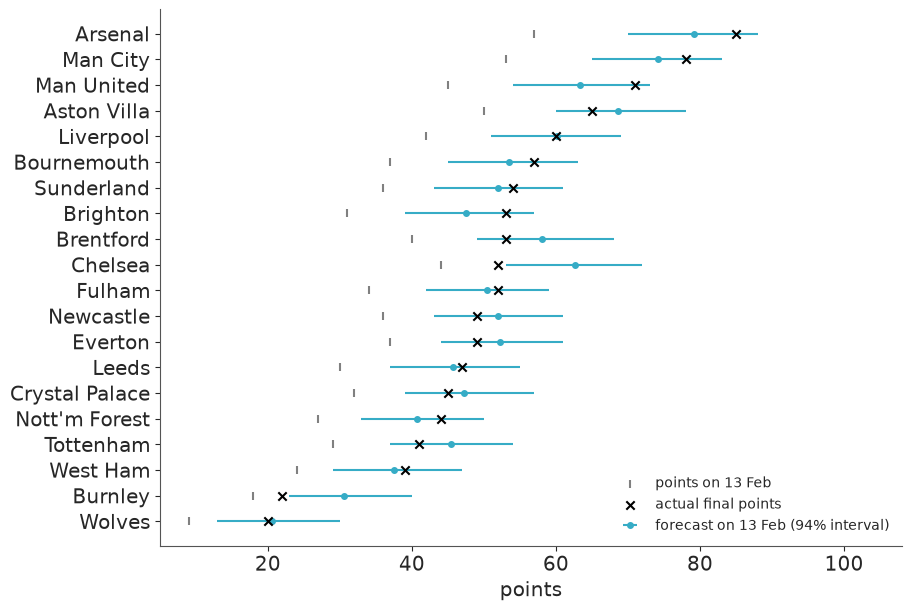

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
ypos = np.arange(len(outlook))[::-1]
ax.errorbar(outlook.exp_pts, ypos, xerr=[outlook.exp_pts - outlook.lo, outlook.hi - outlook.exp_pts],
            fmt="o", ms=4, label="forecast on 13 Feb (94% interval)")
ax.scatter(outlook.pts_13_feb, ypos, marker="|", color="0.5", label="points on 13 Feb")
ax.scatter(outlook.actual_pts, ypos, marker="x", color="k", zorder=3, label="actual final points")
ax.set(yticks=ypos, yticklabels=outlook.index, xlabel="points", xlim=(5, 108))
ax.legend(loc="lower right", fontsize=10);

In [25]:
inside = ((outlook.actual_pts >= outlook.lo) & (outlook.actual_pts <= outlook.hi))
print(f"final points inside the 94% interval: {inside.sum()} of {len(outlook)}; outside: {list(outlook.index[~inside])}")
print("actual top 4:     ", list(final.index[:4]))
print("model's top 4:    ", list(outlook.P_top4.sort_values(ascending=False).index[:4]))
print("actually relegated:", list(final.index[-3:]))
print("model's bottom 3:  ", list(outlook.P_relegation.sort_values(ascending=False).index[:3]))

# How much of the forecast uncertainty is football, and how much is not knowing the team strengths?
# Re-simulate with every scoring rate fixed at its posterior mean: only match-day randomness is left.
mu_home_fixed = np.repeat(sims["mu_home"].values.mean(axis=1, keepdims=True), hg_sim.shape[1], axis=1)
mu_away_fixed = np.repeat(sims["mu_away"].values.mean(axis=1, keepdims=True), hg_sim.shape[1], axis=1)
pts_fixed, _, _ = simulate_tables(league_table(played), remaining, rng.poisson(mu_home_fixed), rng.poisson(mu_away_fixed), teams26, rng)
print(f"sd of final points, averaged over teams: {pts_sim.std(axis=1).mean():.2f} with full uncertainty, "
      f"{pts_fixed.std(axis=1).mean():.2f} with team strengths fixed at their posterior means")

final points inside the 94% interval: 18 of 20; outside: ['Chelsea', 'Burnley']
actual top 4:      ['Arsenal', 'Man City', 'Man United', 'Aston Villa']
model's top 4:     ['Arsenal', 'Man City', 'Aston Villa', 'Man United']
actually relegated: ['West Ham', 'Burnley', 'Wolves']
model's bottom 3:   ['Wolves', 'Burnley', 'West Ham']
sd of final points, averaged over teams: 4.78 with full uncertainty, 4.42 with team strengths fixed at their posterior means


In [26]:
assert h.check(
    "task4",
    p_title_arsenal=outlook.P_title["Arsenal"],
    p_relegation_west_ham=outlook.P_relegation["West Ham"],
    expected_points_arsenal=outlook.exp_pts["Arsenal"],
)

- PASS `p_title_arsenal` = 0.7235 is consistent with the reference solution.
- PASS `p_relegation_west_ham` = 0.6088 is consistent with the reference solution.
- PASS `expected_points_arsenal` = 79.15 is consistent with the reference solution.

On 13 February the model made Arsenal clear but not overwhelming title favourites (about
70%, Manchester City most of the rest), and named Wolves, Burnley and West Ham as the most
likely relegated sides, West Ham at roughly 60%. Arsenal won the league and exactly those
three went down. The model's four most likely top-four finishers were the actual top four,
but do not read much into that: the last place was close to a coin toss between Manchester
United (44%) and Chelsea (41%), and it happened to fall the model's way.

More important than the hits: **calibration**. 18 of 20 final totals fall inside their
94% intervals, where we would expect about 19. The two misses are instructive. Chelsea
took 8 points from their last 12 matches after 44 from 26, and Burnley took 4. At the other
end, Manchester United's 26 points from 12 matches only just stayed inside their interval.
The model assumes a team's strength is constant over the season; form, injuries, managerial
changes and fixture congestion are all outside it.

Note how wide the intervals are: roughly ±9 points with 12 matches to go. Most of that is
irreducible match-day randomness, not parameter uncertainty: fixing every team's strength
at its posterior mean only reduces the sd of final points from 4.8 to 4.4. Better ratings
would not make these intervals much narrower. A desk that publishes "Arsenal will finish on
79 points" rather than "between 70 and 88" is selling false precision.

## Task 5 · Your numbers next to the bookmaker's

The sceptic's test. For each of the 120 held-out matches, the model and the bookmaker each
give three probabilities (home win, draw, away win), and then one of the three happened.

Two proper scoring rules, both "lower is better", averaged over matches, where $p_{ik}$ is
the probability given to outcome $k$ in match $i$ and $o_{ik}$ is 1 if it happened, else 0:

$$\text{log score} = -\frac{1}{N}\sum_i \log p_{i,\text{observed}} \qquad\qquad
\text{Brier} = \frac{1}{N}\sum_i \sum_{k \in \{H,D,A\}} (p_{ik} - o_{ik})^2$$

**Deliver**
1. Model probabilities for H/D/A for every held-out match, from the Task 4 posterior.
2. Bookmaker probabilities from the Bet365 odds. Raw inverse odds do not sum to one; how
   big is the bookmaker's margin (the "overround"), and what do you do about it?
3. A reference forecaster that knows nothing about teams.
4. A table of both scores for all three forecasters - and a statement about whether 120
   matches are enough to separate them. Quantify it.

### Solution

The outcome probabilities could be read off the simulated scores of Task 4, but with 4000
draws they would carry Monte Carlo noise of up to about 0.008 each. We have the posterior
draws of the scoring *rates* for each fixture, so we can do without that noise and compute the
probabilities exactly: for each draw the score matrix is an outer product of two Poisson
pmfs; average over draws (that is the posterior predictive), then sum the lower triangle
(home win), diagonal (draw) and upper triangle (away win).

In [27]:
def outcome_probabilities(mu_home, mu_away, max_goals=12):
    """P(home win), P(draw), P(away win) per match from rate draws of shape (match, sample)."""
    g = np.arange(max_goals + 1)
    pmf_home = stats.poisson.pmf(g[None, :, None], mu_home[:, None, :])  # (match, goals, sample)
    pmf_away = stats.poisson.pmf(g[None, :, None], mu_away[:, None, :])
    score = np.einsum("mis,mjs->mij", pmf_home, pmf_away) / mu_home.shape[1]  # posterior predictive score matrix
    probs = np.stack([np.tril(score, -1).sum((1, 2)), np.trace(score, axis1=1, axis2=2), np.triu(score, 1).sum((1, 2))], axis=1)
    return probs / probs.sum(axis=1, keepdims=True)


p_model = outcome_probabilities(sims["mu_home"].values, sims["mu_away"].values)

inverse_odds = 1 / remaining[["B365H", "B365D", "B365A"]].values
overround = inverse_odds.sum(axis=1) - 1
p_bookmaker = inverse_odds / inverse_odds.sum(axis=1, keepdims=True)

base_rates = played.FTR.value_counts(normalize=True).loc[["H", "D", "A"]].values
p_base = np.tile(base_rates, (len(remaining), 1))

print(f"mean overround: {overround.mean():.3f}")
print("base rates H/D/A from the first 26 rounds:", base_rates.round(3))

mean overround: 0.055
base rates H/D/A from the first 26 rounds: [0.431 0.265 0.304]


In [28]:
outcome = remaining.FTR.map({"H": 0, "D": 1, "A": 2}).values
onehot = np.eye(3)[outcome]


def log_scores(p):
    return -np.log(p[np.arange(len(outcome)), outcome])


def brier_scores(p):
    return ((p - onehot) ** 2).sum(axis=1)


forecasters = {"model": p_model, "bookmaker": p_bookmaker, "base rates": p_base}
scores = pd.DataFrame({
    "log score": {k: log_scores(p).mean() for k, p in forecasters.items()},
    "Brier": {k: brier_scores(p).mean() for k, p in forecasters.items()},
})
scores.round(4)

,log score,Brier
model,1.0523,0.6322
bookmaker,1.0352,0.6221
base rates,1.0853,0.6573


In [29]:
def paired_difference(a, b):
    d = log_scores(forecasters[a]) - log_scores(forecasters[b])
    return pd.Series({"mean difference in log score": d.mean(), "standard error": d.std(ddof=1) / np.sqrt(len(d))})


pd.DataFrame({
    "model - bookmaker": paired_difference("model", "bookmaker"),
    "base rates - model": paired_difference("base rates", "model"),
}).T.round(4)

,mean difference in log score,standard error
model - bookmaker,0.0171,0.0189
base rates - model,0.0329,0.0196


In [30]:
assert h.check(
    "task5",
    overround=overround.mean(),
    log_score_bookmaker=log_scores(p_bookmaker).mean(),
    log_score_model=log_scores(p_model).mean(),
)

- PASS `overround` = 0.05547 is consistent with the reference solution.
- PASS `log_score_bookmaker` = 1.035 is consistent with the reference solution.
- PASS `log_score_model` = 1.052 is consistent with the reference solution.

Bet365's odds imply probabilities that sum to about 1.055: a 5.5% margin. Dividing by the
sum (proportional normalisation) is the simplest way to remove it.

**The bookmaker wins**, on both scores. Our model sits between the bookmaker and the
know-nothing baseline, a little closer to the bookmaker. But look at the standard errors of
the paired differences: each gap is about one to two standard errors. With 120 matches we
cannot formally separate *any* pair of these forecasters - football results are so noisy
that a useful edge in log score is a few hundredths, and measuring that takes many hundreds
of matches. The honest summary for the head of desk: "as expected, no evidence that we
beat the market; mild evidence that we beat nothing at all; ask me again in three seasons".

## Task 6 · Would you bet on it?

The head of desk reads your table and asks the natural follow-up: *"Fine, the market is
better on average. But when your model disagrees with it - is there money in that? And
what does the market know that your model does not?"*

**Deliver**
1. A back-test on the held-out matches: stake 1 unit on every outcome where your model
   sees positive expected value at the Bet365 odds (the real odds, margin included). Number of
   bets, profit, return on investment - **with an uncertainty interval** on the ROI.
2. A diagnosis of *how* the model's probabilities differ from the market's. Is the model
   more or less opinionated? If you mix the two forecasts, `w * model + (1 - w) * market`,
   which `w` scores best on the held-out matches, and what does that tell you?
3. A recommendation in three sentences. What is the model good for, what is it not good
   for, and what would you add first?

In [31]:
odds = remaining[["B365H", "B365D", "B365A"]].values
expected_value = p_model * odds - 1  # per unit staked, if the model were right
bets = expected_value > 0
profit = np.where(onehot == 1, odds - 1, -1.0) * bets  # (match, outcome)

boot = []
for _ in range(5000):
    i = rng.integers(0, len(remaining), len(remaining))  # resample matches
    boot.append(profit[i].sum() / bets[i].sum())

print(f"bets placed: {bets.sum()} of {bets.size} possible (H/D/A: {bets.sum(axis=0)})")
print(f"profit: {profit.sum():+.1f} units, ROI {profit.sum() / bets.sum():+.1%}")
roi_lo, roi_hi = np.quantile(boot, [0.03, 0.97])
print(f"94% bootstrap interval for ROI: [{roi_lo:+.0%}, {roi_hi:+.0%}]")
print(f"for reference, ROI of betting every outcome of every match: {np.where(onehot == 1, odds - 1, -1.0).mean():+.1%}")

bets placed: 150 of 360 possible (H/D/A: [58 37 55])
profit: -4.7 units, ROI -3.2%
94% bootstrap interval for ROI: [-29%, +24%]
for reference, ROI of betting every outcome of every match: -1.4%


sd of P(home win) across matches:  model 0.100   bookmaker 0.169
mean probability of H/D/A:  model [0.44  0.244 0.316]   bookmaker [0.439 0.24  0.321]   what happened [0.417 0.292 0.292]
mean |model - bookmaker| for H/D/A: [0.078 0.023 0.069]


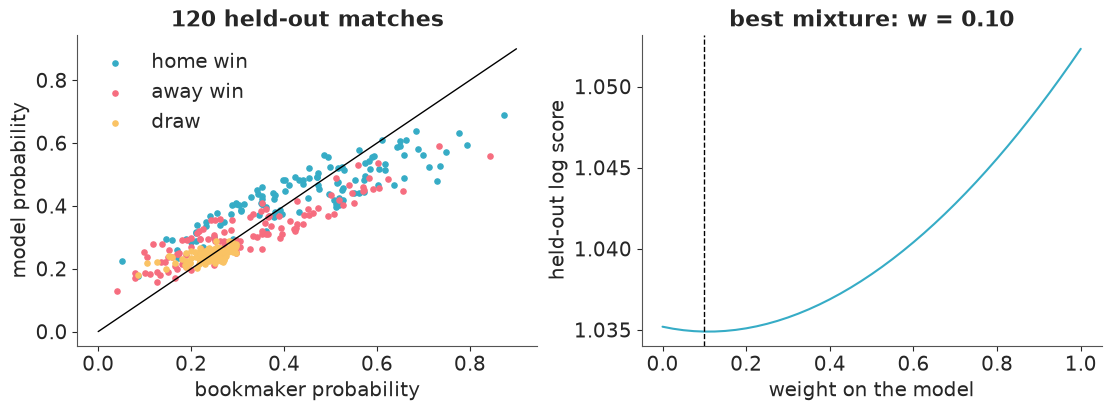

In [32]:
weights = np.linspace(0, 1, 41)
blend_scores = [log_scores(w * p_model + (1 - w) * p_bookmaker).mean() for w in weights]
best_w = weights[int(np.argmin(blend_scores))]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(p_bookmaker[:, 0], p_model[:, 0], s=14, label="home win")
axes[0].scatter(p_bookmaker[:, 2], p_model[:, 2], s=14, label="away win")
axes[0].scatter(p_bookmaker[:, 1], p_model[:, 1], s=14, label="draw")
axes[0].plot([0, 0.9], [0, 0.9], color="k", lw=1)
axes[0].set(xlabel="bookmaker probability", ylabel="model probability", title="120 held-out matches")
axes[0].legend()
axes[1].plot(weights, blend_scores)
axes[1].axvline(best_w, color="k", ls="--", lw=1)
axes[1].set(xlabel="weight on the model", ylabel="held-out log score", title=f"best mixture: w = {best_w:.2f}")

print("sd of P(home win) across matches:  model %.3f   bookmaker %.3f" % (p_model[:, 0].std(), p_bookmaker[:, 0].std()))
print("mean probability of H/D/A:  model", p_model.mean(axis=0).round(3), "  bookmaker", p_bookmaker.mean(axis=0).round(3),
      "  what happened", onehot.mean(axis=0).round(3))
print("mean |model - bookmaker| for H/D/A:", np.abs(p_model - p_bookmaker).mean(axis=0).round(3));

In [33]:
assert h.check("task6", best_blend_weight=best_w)

- PASS `best_blend_weight` = 0.1 is consistent with the reference solution.

**The back-test.** The model "finds value" in 150 bets - which should already make you
suspicious: a market this liquid does not misprice 40% of all outcomes. The realised ROI is
a few percent negative, about what the bookmaker's margin predicts for someone betting
without an edge, and the bootstrap interval runs from about -30% to +25%. For scale:
blindly backing every outcome of every match lost only 1.4% on these matches, less than
the margin - that is how noisy 120 matches are. They can neither prove nor disprove an
edge; the prior expectation (no edge) stands.

**The diagnosis.** On average the two forecasters agree almost exactly: 44% home wins, 24%
draws, 32% away wins. So the market, too, believes in this season's larger home advantage
(and both expected fewer draws than the 29% that happened). The difference is in the
spread, and the scatter is the most useful picture in this notebook. The two forecasters
agree on the ordering of matches, but the cloud is *flatter* than the diagonal: where the
market says 75%, the model says 60%; where the market says 15%, the model says 20-25%. The
sd of the home-win probability across matches is 0.10 for the model and 0.17 for the
market. Our model is **less** opinionated than the market, not more. That is the hierarchical
prior at work: after 26 matches it shrinks Arsenal and Wolves towards the average, because
from goals alone it cannot rule out luck. The market can, because it knows things our model
does not: previous seasons, squad value, injuries, expected goals, line-ups. The best
mixture puts a weight of only about 0.1 on the model - on these matches it adds next to
nothing to the market's forecast.

**Recommendation.** Publish the model for what it is good at: transparent team ratings
with honest uncertainty, and season simulations (title, top four, relegation) that the odds
for single matches do not give you and that proved well calibrated. Do not use it to
second-guess match odds, and do not bet with it. The diagnosis says our ratings are too
timid, not too bold, so the first thing to add is information that sharpens them faster than
goals can: shots or expected goals, and what we knew before the season started.

## Going further

- **Last season as a prior.** Fit both seasons jointly, with a 2025/26 rating centred on
  a fraction of the 2024/25 rating and a separate prior for promoted teams. Does it score
  better on the held-out matches? (A quick attempt of ours scored 1.056 against 1.052 for
  the single-season model at round 26 - no better - and its sampler diagnostics needed work.
  Does it help at round 8, when the current season says little?)
- **Dependent scores.** Task 3 found home and away goals more negatively correlated than
  the model allows, and the run-in had more draws than either forecaster expected. Add the
  low-score correction of Dixon & Coles (1997) with `pm.Potential` or `pm.CustomDist`, or a
  match-level random effect shared by both sides with opposite signs. Does the log score improve?
- **Time-varying strength.** Chelsea and Burnley broke the model in Task 4. Let
  ratings follow a `pm.GaussianRandomWalk` over match rounds. Is there evidence that form
  is real, or is it noise?
- **Better data.** Shots on target (`HST`, `AST`) are about three times as plentiful as
  goals. Model them jointly with goals and see whether ratings sharpen faster early in the
  season.

In [34]:
h.progress()

**C02**: 0/20 hints used, 14/14 checks passed.